# CARS DATASET ANALYSIS - AUTOMOTIVE ANALYTICS & PRICE PREDICTION

## Dataset: Cars Dataset
**Kaynak:** https://www.kaggle.com/datasets/ayushparwal2026/cars-dataset

## Proje Hedefi: ARABA FIYAT TAHMINI & MARKET INSIGHTS

## Proje Ozellikleri:
- **Price Prediction** - Regression models
- **Brand & Model Analysis** - Market segmentation
- **Feature Importance** - Mileage, Year, Engine impact
- **Car Segmentation** - Clustering analysis
- **Market Insights** - Automotive business intelligence
- **12+ ML Models** - Comprehensive comparison
- **30+ Visualizations** - Automotive-focused graphs

## Proje Adimlari:
1. Veri Yukleme & Automotive Structure
2. **AUTOMOTIVE EDA** (20+ graphs)
3. **BRAND & MODEL ANALYSIS**
4. **PRICE ANALYSIS** (Distribution, trends)
5. Feature Engineering (Car-specific)
6. **12+ REGRESSION MODELS**
7. **CAR SEGMENTATION** (Clustering)
8. **COMPREHENSIVE COMPARISON** (Visual + Table)
9. Market Insights & Recommendations

## 1. KUTUPHANELER

In [1]:
# Temel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Sistem
import os
import subprocess
import zipfile
import glob

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Install CatBoost if not available
try:
    from catboost import CatBoostRegressor
except ImportError:
    print("CatBoost not found. Installing...")
    !pip install catboost -qq
    from catboost import CatBoostRegressor

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

# Plotly
try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY = True
except:
    PLOTLY = False

# Viz
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('='*80)
print('CARS DATASET ANALYSIS - KUTUPHANELER YUKLENDI!')
print('='*80)
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'Plotly: {"Available" if PLOTLY else "Not Available"}')
print('='*80)

CatBoost not found. Installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.3 MB/s eta 0:00:00
CARS DATASET ANALYSIS - KUTUPHANELER YUKLENDI!
NumPy: 2.0.2
Pandas: 2.2.2
Plotly: Available


## 2. VERI YUKLEME

In [2]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)
    full_zip_path = os.path.join(dest_folder, zip_filename)
    print(f"Indiriliyor: {zip_filename}")
    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        return True
    except:
        return False

def extract_dataset(dest_folder):
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        for zip_file in zip_files:
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
        return True
    except:
        return False

In [3]:
dataset_folder = "cars_dataset"
os.makedirs(dataset_folder, exist_ok=True)

dataset_info = {
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/ayushparwal2026/cars-dataset",
    "folder": dataset_folder,
    "zip_filename": "cars.zip"
}

csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if not csv_files:
    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )
    if success:
        extract_dataset(dataset_info["folder"])
else:
    print("Dataset mevcut!")

Indiriliyor: cars.zip


In [4]:
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if csv_files:
    df = pd.read_csv(csv_files[0])

    print('='*80)
    print('VERI YUKLENDI!')
    print('='*80)
    print(f'Toplam Kayit: {len(df):,}')
    print(f'Sutun Sayisi: {len(df.columns)}')
    print(f'Bellek: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
    print('='*80)
else:
    print('CSV bulunamadi!')

VERI YUKLENDI!
Toplam Kayit: 7,253
Sutun Sayisi: 14
Bellek: 3.75 MB


In [5]:
print('ILK 10 KAYIT:')
df.head(10)

ILK 10 KAYIT:


,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.00,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.00,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.00,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.00,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.00,NaN,17.74
5,5,Hyundai EON LPG Era Plus Option,Hyderabad,2012,75000,LPG,Manual,First,21.1 km/kg,814 CC,55.2 bhp,5.00,NaN,2.35
6,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.00,NaN,3.50
7,7,Toyota Innova Crysta 2.8 GX AT 8S,Mumbai,2016,36000,Diesel,Automatic,First,11.36 kmpl,2755 CC,171.5 bhp,8.00,21 Lakh,17.50
8,8,Volkswagen Vento Diesel Comfortline,Pune,2013,64430,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.00,NaN,5.20
9,9,Tata Indica Vista Quadrajet LS,Chennai,2012,65932,Diesel,Manual,Second,22.3 kmpl,1248 CC,74 bhp,5.00,NaN,1.95


In [6]:
print('VERI YAPISI:')
print('='*80)
df.info()

VERI YAPISI:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   object 
 9   Engine             7207 non-null   object 
 10  Power              7207 non-null   object 
 11  Seats              7200 non-null   float64
 12  New_Price          1006 non-null   object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 793.4+ KB


In [7]:
print('SUTUNLAR:')
for i, col in enumerate(df.columns, 1):
    print(f'{i:2d}. {col}')

SUTUNLAR:
 1. S.No.
 2. Name
 3. Location
 4. Year
 5. Kilometers_Driven
 6. Fuel_Type
 7. Transmission
 8. Owner_Type
 9. Mileage
10. Engine
11. Power
12. Seats
13. New_Price
14. Price


In [8]:
print('ISTATISTIKSEL OZET:')
print('='*80)
df.describe(include='all').T

ISTATISTIKSEL OZET:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
S.No.,7253.00,NaN,NaN,NaN,3626.00,2093.91,0.00,1813.00,3626.00,5439.00,7252.00
Name,7253,2041,Mahindra XUV500 W8 2WD,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,7253,11,Mumbai,949,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,7253.00,NaN,NaN,NaN,2013.37,3.25,1996.00,2011.00,2014.00,2016.00,2019.00
Kilometers_Driven,7253.00,NaN,NaN,NaN,58699.06,84427.72,171.00,34000.00,53416.00,73000.00,6500000.00
Fuel_Type,7253,5,Diesel,3852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,7253,2,Manual,5204,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner_Type,7253,4,First,5952,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mileage,7251,450,17.0 kmpl,207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine,7207,150,1197 CC,732,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. AUTOMOTIVE EDA

### Target Variable - Price

TARGET: Price
Ortalama: $9.48
Medyan: $5.64
Min: $0.44
Max: $160.00
Std: $11.19


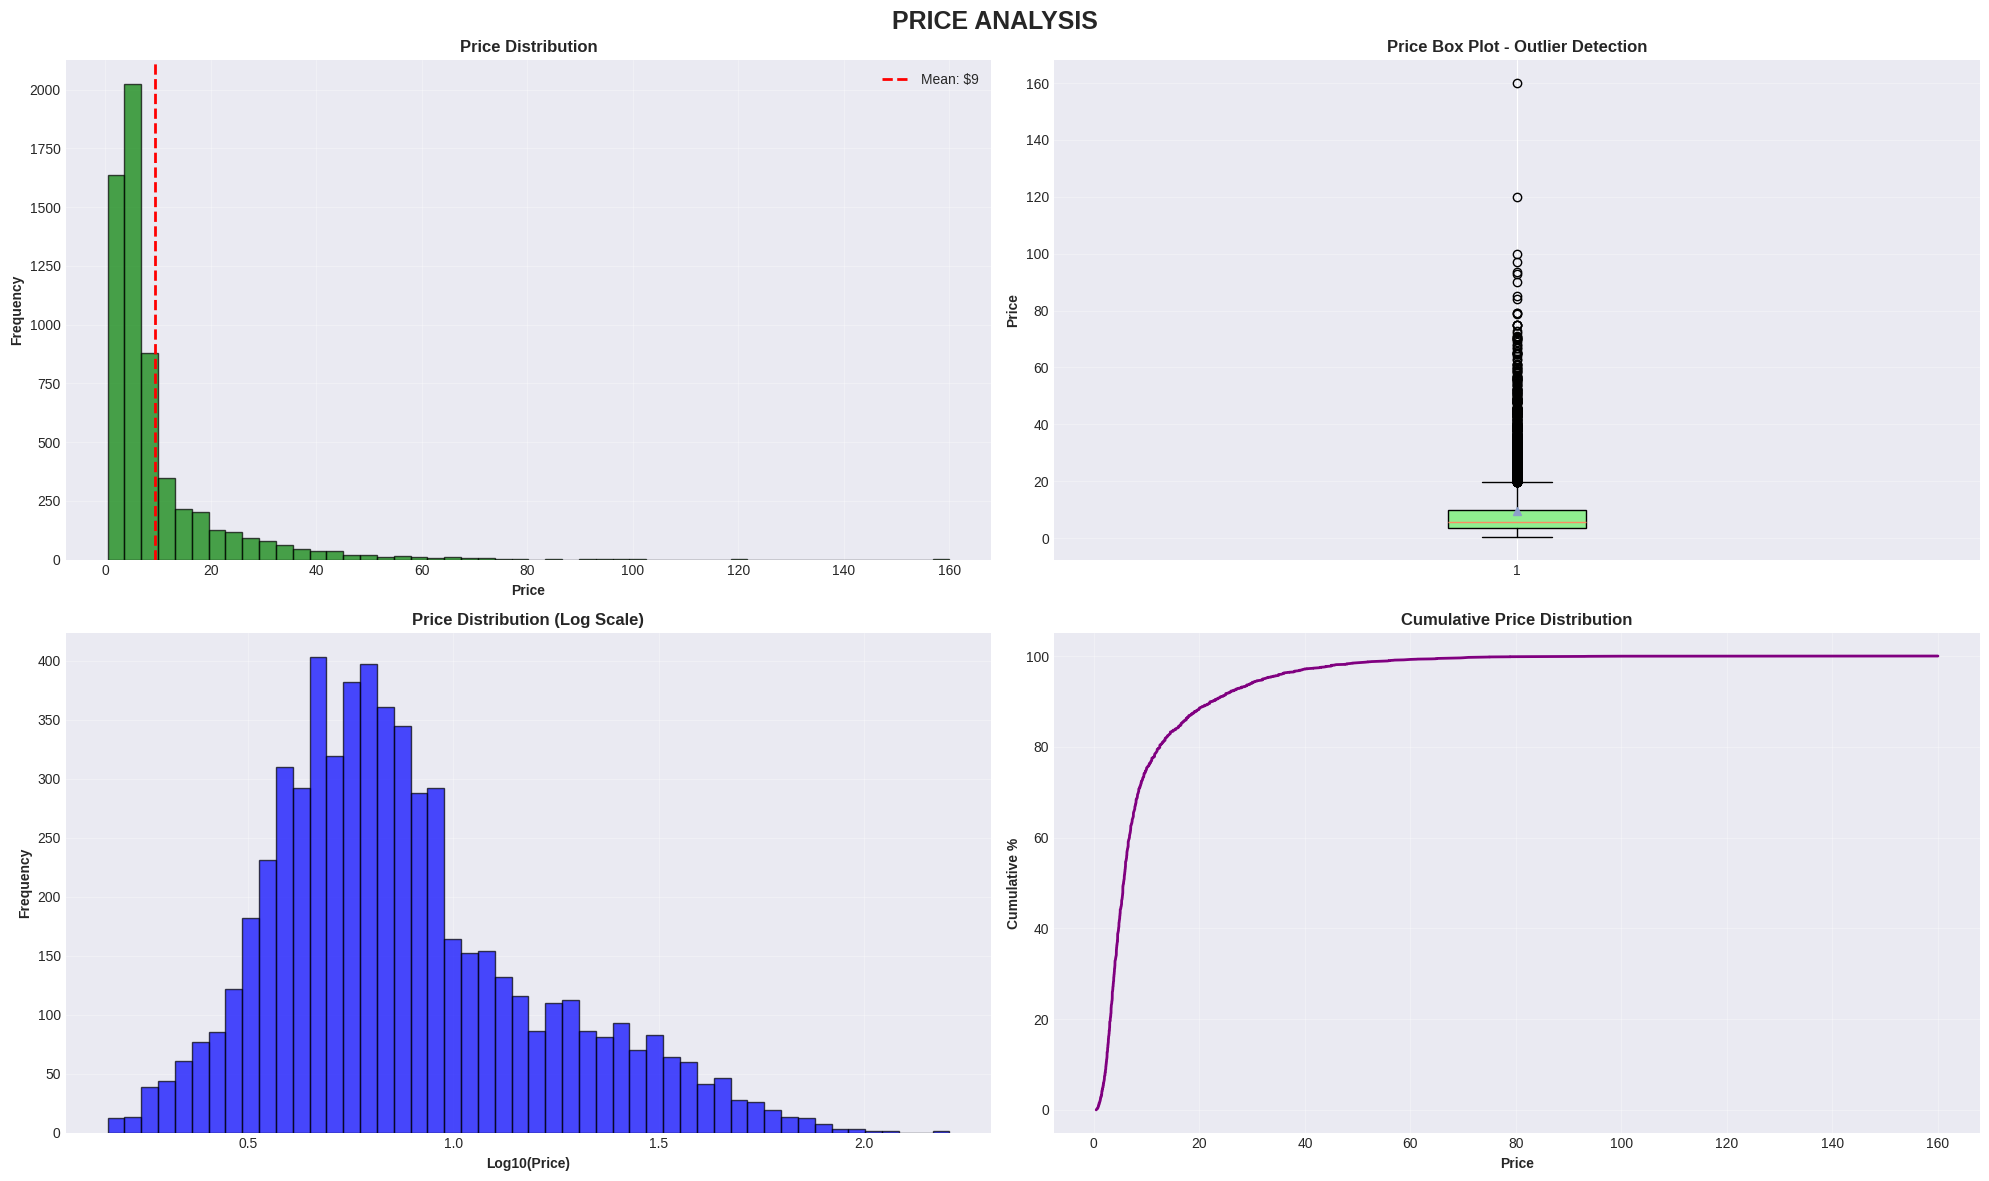

In [9]:
# Price column
# The 'New_Price' column caused a TypeError due to string values like '8.61 Lakh'.
# For 'Price Prediction', the 'Price' column (float64) is more suitable as it is already numeric.
price_col = 'Price'

print('='*80)
print(f'TARGET: {price_col}')
print('='*80)
print(f'Ortalama: ${df[price_col].mean():,.2f}')
print(f'Medyan: ${df[price_col].median():,.2f}')
print(f'Min: ${df[price_col].min():,.2f}')
print(f'Max: ${df[price_col].max():,.2f}')
print(f'Std: ${df[price_col].std():,.2f}')

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('PRICE ANALYSIS', fontsize=18, fontweight='bold')

# Histogram
axes[0, 0].hist(df[price_col].dropna(), bins=50, color='green', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df[price_col].mean(), color='red', linestyle='--', linewidth=2,
                  label=f'Mean: ${df[price_col].mean():,.0f}')
axes[0, 0].set_xlabel('Price', fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontweight='bold')
axes[0, 0].set_title('Price Distribution', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Box plot
bp = axes[0, 1].boxplot([df[price_col].dropna()], patch_artist=True, showmeans=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')
axes[0, 1].set_ylabel('Price', fontweight='bold')
axes[0, 1].set_title('Price Box Plot - Outlier Detection', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Log scale
axes[1, 0].hist(np.log10(df[price_col].dropna() + 1), bins=50, color='blue', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Log10(Price)', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Price Distribution (Log Scale)', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Cumulative
sorted_prices = np.sort(df[price_col].dropna())
cumulative = np.arange(1, len(sorted_prices) + 1) / len(sorted_prices) * 100
axes[1, 1].plot(sorted_prices, cumulative, linewidth=2, color='purple')
axes[1, 1].set_xlabel('Price', fontweight='bold')
axes[1, 1].set_ylabel('Cumulative %', fontweight='bold')
axes[1, 1].set_title('Cumulative Price Distribution', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Brand & Model Analysis

BRAND ANALYSIS
Total Brands: 33

Top 10 Brands:
Brand
Maruti           1444
Hyundai          1340
Honda             743
Toyota            507
Mercedes-Benz     380
Volkswagen        374
Ford              351
Mahindra          331
BMW               312
Audi              285
Name: count, dtype: int64


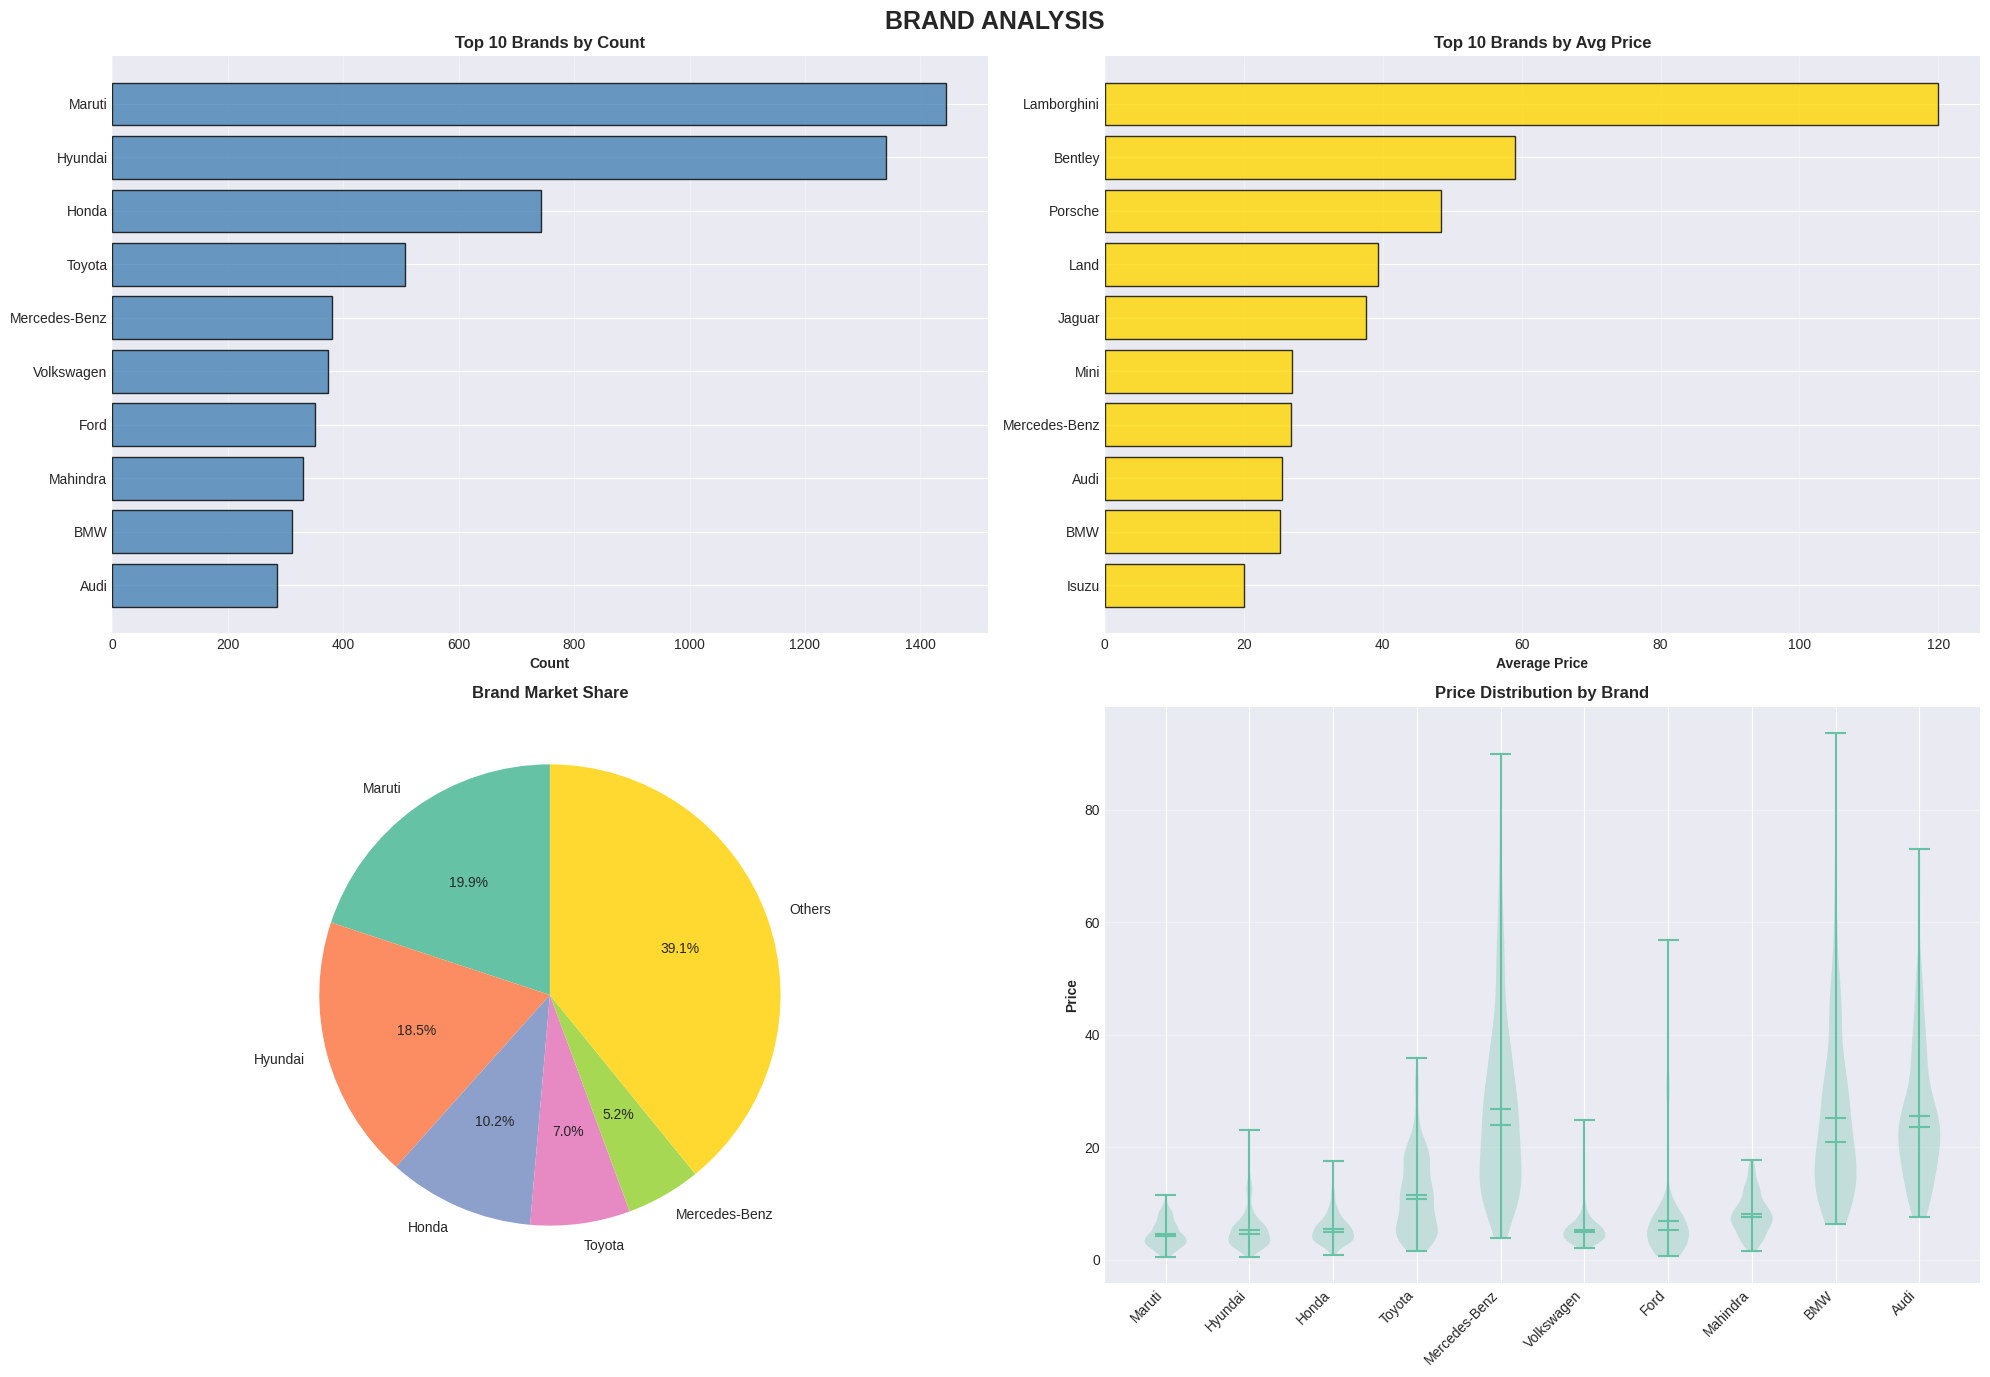

In [11]:
# Brand Extraction from 'Name'
# The dataset doesn't have a specific 'Brand' column, so we extract it from 'Name'
df['Brand'] = df['Name'].str.split(' ').str[0]
brand_col = 'Brand'

print('='*80)
print('BRAND ANALYSIS')
print('='*80)
print(f'Total Brands: {df[brand_col].nunique()}')
print('\nTop 10 Brands:')
print(df[brand_col].value_counts().head(10))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('BRAND ANALYSIS', fontsize=18, fontweight='bold')

# Top 10 brands by count
top_10_brands = df[brand_col].value_counts().head(10)
axes[0, 0].barh(range(len(top_10_brands)), top_10_brands.values,
               color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 0].set_yticks(range(len(top_10_brands)))
axes[0, 0].set_yticklabels(top_10_brands.index)
axes[0, 0].set_xlabel('Count', fontweight='bold')
axes[0, 0].set_title('Top 10 Brands by Count', fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# Top 10 brands by average price
# Ensure price_col is defined, usually 'Price'
if 'Price' in df.columns:
    price_col = 'Price'
    brand_avg_price = df.groupby(brand_col)[price_col].mean().sort_values(ascending=False).head(10)
    axes[0, 1].barh(range(len(brand_avg_price)), brand_avg_price.values,
                   color='gold', edgecolor='black', alpha=0.8)
    axes[0, 1].set_yticks(range(len(brand_avg_price)))
    axes[0, 1].set_yticklabels(brand_avg_price.index)
    axes[0, 1].set_xlabel('Average Price', fontweight='bold')
    axes[0, 1].set_title('Top 10 Brands by Avg Price', fontweight='bold')
    axes[0, 1].invert_yaxis()
    axes[0, 1].grid(axis='x', alpha=0.3)

    # Brand market share
    top_5_brands = df[brand_col].value_counts().head(5)
    others = df[brand_col].value_counts().iloc[5:].sum()
    pie_data = list(top_5_brands.values) + [others]
    pie_labels = list(top_5_brands.index) + ['Others']
    axes[1, 0].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
    axes[1, 0].set_title('Brand Market Share', fontweight='bold')

    # Price by brand (top 10)
    top_10_brand_names = top_10_brands.index
    violin_data = []
    labels = []
    for brand in top_10_brand_names:
        data = df[df[brand_col] == brand][price_col].dropna()
        if len(data) > 0:
            violin_data.append(data)
            labels.append(brand)

    if violin_data:
        axes[1, 1].violinplot(violin_data,
                             positions=range(len(labels)),
                             showmeans=True, showmedians=True)
        axes[1, 1].set_xticks(range(len(labels)))
        axes[1, 1].set_xticklabels(labels, rotation=45, ha='right')
        axes[1, 1].set_ylabel('Price', fontweight='bold')
        axes[1, 1].set_title('Price Distribution by Brand', fontweight='bold')
        axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Year Analysis

YEAR ANALYSIS
Oldest: 1996
Newest: 2019
Average: 2013


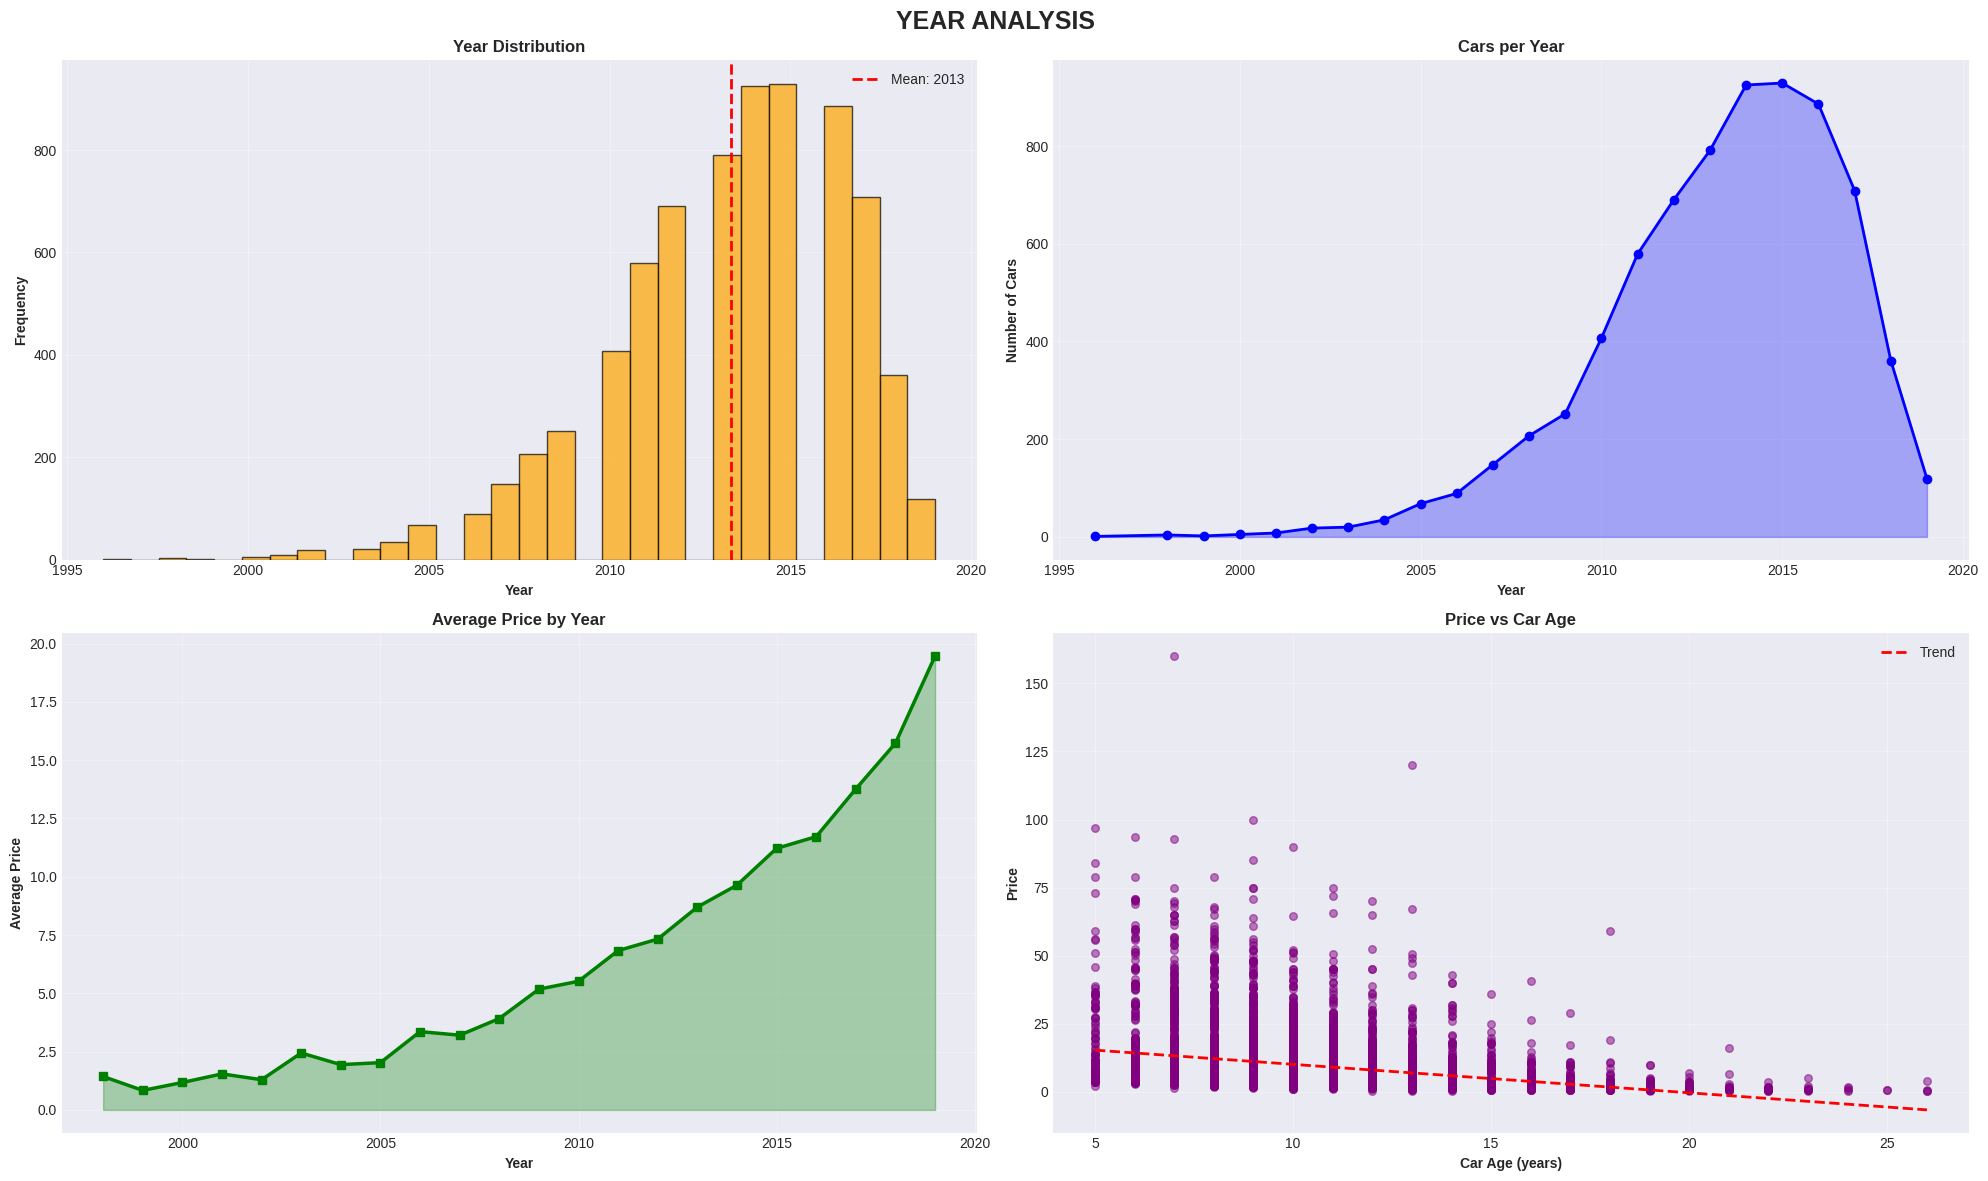

In [12]:
year_cols = [col for col in df.columns if 'year' in col.lower()]

if year_cols:
    year_col = year_cols[0]

    print('='*80)
    print('YEAR ANALYSIS')
    print('='*80)
    print(f'Oldest: {df[year_col].min()}')
    print(f'Newest: {df[year_col].max()}')
    print(f'Average: {df[year_col].mean():.0f}')

    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    fig.suptitle('YEAR ANALYSIS', fontsize=18, fontweight='bold')

    # Year distribution
    axes[0, 0].hist(df[year_col].dropna(), bins=30, color='orange', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df[year_col].mean(), color='red', linestyle='--', linewidth=2,
                      label=f'Mean: {df[year_col].mean():.0f}')
    axes[0, 0].set_xlabel('Year', fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontweight='bold')
    axes[0, 0].set_title('Year Distribution', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # Cars per year
    year_counts = df[year_col].value_counts().sort_index()
    axes[0, 1].plot(year_counts.index, year_counts.values, marker='o', linewidth=2, color='blue')
    axes[0, 1].fill_between(year_counts.index, year_counts.values, alpha=0.3, color='blue')
    axes[0, 1].set_xlabel('Year', fontweight='bold')
    axes[0, 1].set_ylabel('Number of Cars', fontweight='bold')
    axes[0, 1].set_title('Cars per Year', fontweight='bold')
    axes[0, 1].grid(alpha=0.3)

    # Average price by year
    year_price = df.groupby(year_col)[price_col].mean().sort_index()
    axes[1, 0].plot(year_price.index, year_price.values, marker='s', linewidth=2.5,
                   color='green', markersize=6)
    axes[1, 0].fill_between(year_price.index, year_price.values, alpha=0.3, color='green')
    axes[1, 0].set_xlabel('Year', fontweight='bold')
    axes[1, 0].set_ylabel('Average Price', fontweight='bold')
    axes[1, 0].set_title('Average Price by Year', fontweight='bold')
    axes[1, 0].grid(alpha=0.3)

    # Age calculation
    current_year = 2024
    df['car_age'] = current_year - df[year_col]

    # Price vs Age
    axes[1, 1].scatter(df['car_age'], df[price_col], alpha=0.5, s=30, color='purple')
    axes[1, 1].set_xlabel('Car Age (years)', fontweight='bold')
    axes[1, 1].set_ylabel('Price', fontweight='bold')
    axes[1, 1].set_title('Price vs Car Age', fontweight='bold')
    axes[1, 1].grid(alpha=0.3)

    # Add trendline
    # Fix: Ensure x and y have same length by dropping NaNs together
    temp_df = df[['car_age', price_col]].dropna()

    if len(temp_df) > 1:
        z = np.polyfit(temp_df['car_age'], temp_df[price_col], 1)
        p = np.poly1d(z)
        axes[1, 1].plot(sorted(temp_df['car_age']), p(sorted(temp_df['car_age'])),
                       "r--", linewidth=2, label='Trend')
        axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

### Numeric Features Analysis

NUMERIC FEATURES (4):
  - S.No.
  - Year
  - Kilometers_Driven
  - Seats

CORRELATION WITH PRICE:
Price               1.00
Year                0.31
Seats               0.05
S.No.               0.02
Kilometers_Driven   0.01
Name: Price, dtype: float64


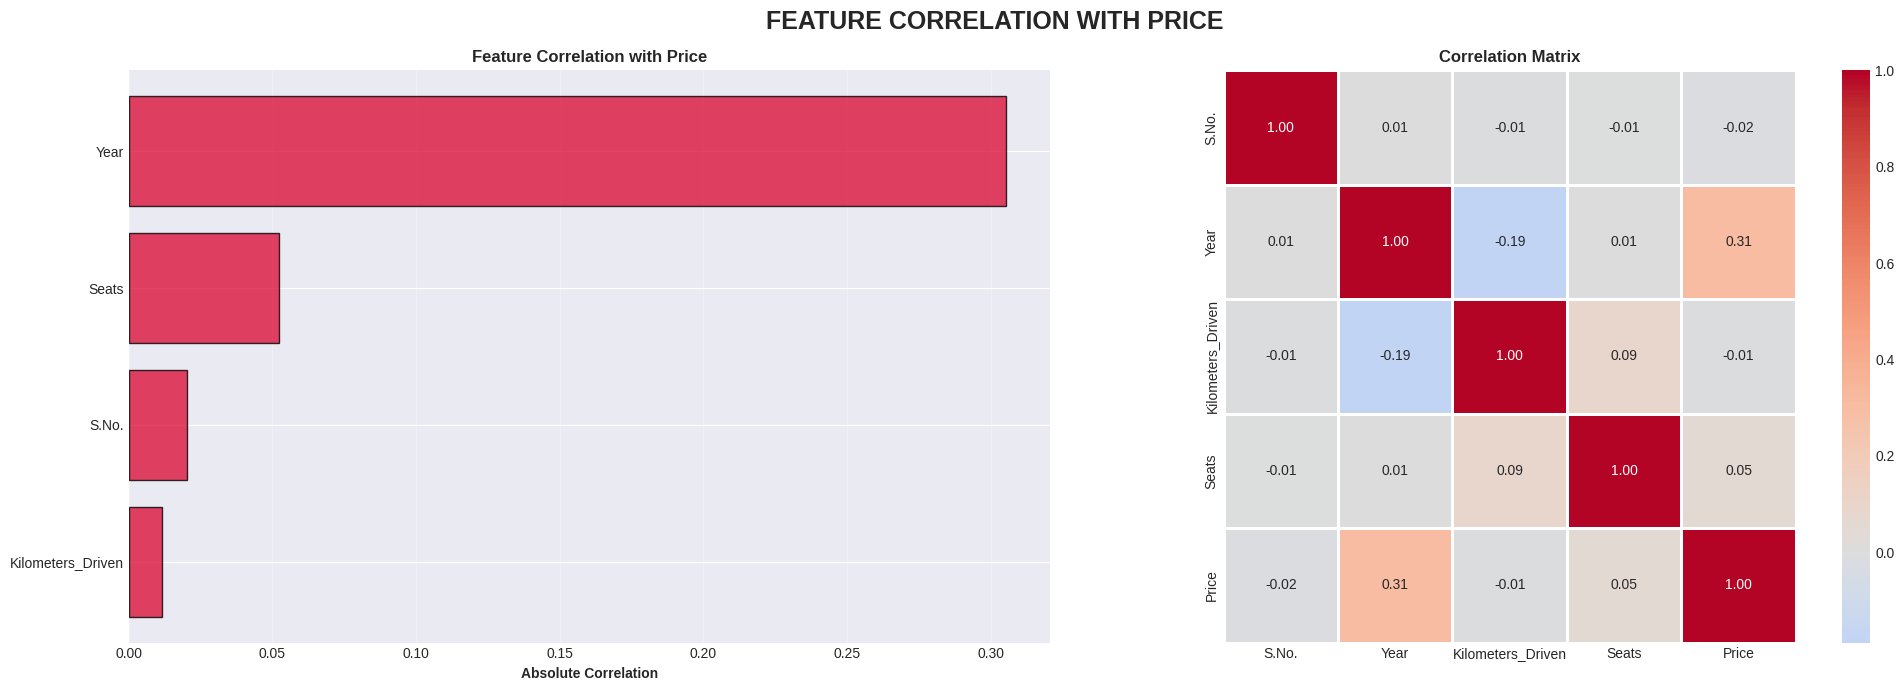

In [13]:
# Get numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if price_col in numeric_cols:
    numeric_cols.remove(price_col)
if 'car_age' in numeric_cols:
    numeric_cols.remove('car_age')

print(f'NUMERIC FEATURES ({len(numeric_cols)}):')
for col in numeric_cols:
    print(f'  - {col}')

# Correlation with price
if len(numeric_cols) > 0:
    correlations = df[numeric_cols + [price_col]].corr()[price_col].abs().sort_values(ascending=False)

    print('\nCORRELATION WITH PRICE:')
    print(correlations)

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    fig.suptitle('FEATURE CORRELATION WITH PRICE', fontsize=18, fontweight='bold')

    # Bar plot
    corr_plot = correlations[correlations.index != price_col]
    axes[0].barh(range(len(corr_plot)), corr_plot.values,
                color='crimson', edgecolor='black', alpha=0.8)
    axes[0].set_yticks(range(len(corr_plot)))
    axes[0].set_yticklabels(corr_plot.index)
    axes[0].set_xlabel('Absolute Correlation', fontweight='bold')
    axes[0].set_title('Feature Correlation with Price', fontweight='bold')
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3)

    # Correlation matrix
    corr_matrix = df[numeric_cols[:10] + [price_col]].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
               center=0, ax=axes[1], square=True, linewidths=1)
    axes[1].set_title('Correlation Matrix', fontweight='bold')

    plt.tight_layout()
    plt.show()

## 4. FEATURE ENGINEERING

In [14]:
print('='*80)
print('FEATURE ENGINEERING - AUTOMOTIVE SPECIFIC')
print('='*80)

df_clean = df.copy()

# Function to clean columns with units (e.g., "19.67 kmpl", "998 CC", "58.16 bhp")
def clean_unit_column(series):
    # Extract numeric part using regex
    return series.astype(str).str.extract(r'([\d\.]+)')[0].astype(float)

# Clean textual numeric columns
print('Cleaning unit columns (Mileage, Engine, Power)...')
for col in ['Mileage', 'Engine', 'Power']:
    if col in df_clean.columns and df_clean[col].dtype == 'object':
        df_clean[col] = clean_unit_column(df_clean[col])
        print(f'  - {col} cleaned')

# 1. Car age
current_year = 2024
if 'Year' in df_clean.columns:
    df_clean['car_age'] = current_year - df_clean['Year']
    print('car_age: Created')

# 2. Age categories
if 'car_age' in df_clean.columns:
    df_clean['age_category'] = pd.cut(df_clean['car_age'],
                                      bins=[0, 5, 10, 15, 100],
                                      labels=['New', 'Recent', 'Old', 'Vintage'])
    print('age_category: Created')

# 3. Price categories (Price is in Lakhs, e.g., 9.5)
if price_col in df_clean.columns:
    df_clean['price_category'] = pd.cut(df_clean[price_col],
                                        bins=[0, 4, 8, 15, np.inf],
                                        labels=['Budget', 'Economy', 'Premium', 'Luxury'])
    print('price_category: Created (Bins: 0-4-8-15+ Lakhs)')

# 4. KM Driven categories (Using Kilometers_Driven)
if 'Kilometers_Driven' in df_clean.columns:
    df_clean['km_category'] = pd.cut(df_clean['Kilometers_Driven'],
                                          bins=[0, 30000, 60000, 100000, np.inf],
                                          labels=['Low', 'Medium', 'High', 'VeryHigh'])
    print('km_category: Created from Kilometers_Driven')

# 5. Engine size categories (Engine is in CC, e.g., 1200)
if 'Engine' in df_clean.columns:
    df_clean['engine_category'] = pd.cut(df_clean['Engine'],
                                         bins=[0, 1000, 1500, 2000, 3000, np.inf],
                                         labels=['Small', 'Compact', 'Medium', 'Large', 'Performance'])
    print('engine_category: Created from Engine (CC)')

print(f'\nTotal columns: {len(df_clean.columns)}')
print('='*80)

FEATURE ENGINEERING - AUTOMOTIVE SPECIFIC
Cleaning unit columns (Mileage, Engine, Power)...
  - Mileage cleaned
  - Engine cleaned
  - Power cleaned
car_age: Created
age_category: Created
price_category: Created (Bins: 0-4-8-15+ Lakhs)
km_category: Created from Kilometers_Driven
engine_category: Created from Engine (CC)

Total columns: 20


In [15]:
# Handle missing values
print('MISSING VALUES:')
missing = df_clean.isnull().sum()
if missing.sum() == 0:
    print('No missing values!')
else:
    print(missing[missing > 0])

    # Fill numeric
    for col in df_clean.select_dtypes(include=[np.number]).columns:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    # Fill categorical
    for col in df_clean.select_dtypes(include=['object', 'category']).columns:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

    print('Missing values filled!')

# Remove duplicates
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'{duplicates} duplicates removed!')

print(f'\nClean dataset: {len(df_clean):,} rows')

MISSING VALUES:
Mileage               2
Engine               46
Power               175
Seats                53
New_Price          6247
Price              1234
price_category     1234
engine_category      46
dtype: int64
Missing values filled!

Clean dataset: 7,253 rows


## 5. MODEL PREPARATION

In [16]:
print('='*80)
print('MODEL PREPARATION - REGRESSION')
print('='*80)

# Target
y = df_clean[price_col].values

# Features
X = df_clean.drop(columns=[price_col]).copy()

# Drop ID columns
id_cols = [col for col in X.columns if 'id' in col.lower() or 'index' in col.lower()]
if id_cols:
    X = X.drop(columns=id_cols)
    print(f'Dropped ID columns: {id_cols}')

# Encoding
print('\nEncoding categorical features...')
for col in X.select_dtypes(include=['object', 'category']).columns:
    if X[col].nunique() <= 2:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        print(f'  Binary: {col}')
    else:
        X = pd.get_dummies(X, columns=[col], drop_first=True)
        print(f'  One-hot: {col}')

print(f'\nFeatures: {X.shape[1]}')
print(f'Samples: {len(X):,}')
print(f'Target range: ${y.min():,.2f} - ${y.max():,.2f}')
print('='*80)

MODEL PREPARATION - REGRESSION

Encoding categorical features...
  One-hot: Name
  One-hot: Location
  One-hot: Fuel_Type
  Binary: Transmission
  One-hot: Owner_Type
  One-hot: New_Price
  One-hot: Brand
  One-hot: age_category
  One-hot: price_category
  One-hot: km_category
  One-hot: engine_category

Features: 2735
Samples: 7,253
Target range: $0.44 - $160.00


In [17]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train-Test Split:')
print(f'  Train: {len(X_train):,}')
print(f'  Test: {len(X_test):,}')

# Scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('\nScaling: RobustScaler (better for outliers)')

Train-Test Split:
  Train: 5,802
  Test: 1,451

Scaling: RobustScaler (better for outliers)


## 6. REGRESSION MODELS - 12+ MODELS

In [18]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=1.0, random_state=42),
    'ElasticNet': ElasticNet(alpha=1.0, random_state=42),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=7, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, max_depth=7, random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(iterations=100, depth=7, random_state=42, verbose=False),
    'SVR': SVR(kernel='rbf'),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
}

print(f'{len(models)} REGRESSION MODELS')
for name in models.keys():
    print(f'  - {name}')

14 REGRESSION MODELS
  - Linear Regression
  - Ridge
  - Lasso
  - ElasticNet
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - LightGBM
  - CatBoost
  - SVR
  - KNN
  - AdaBoost
  - Extra Trees


In [19]:
results = {}

print('='*80)
print('MODEL TRAINING')
print('='*80)

for name, model in models.items():
    print(f'\n{name}...')

    try:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        # Metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred) * 100

        results[name] = {
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2,
            'MAPE': mape,
            'predictions': y_pred
        }

        print(f'  RMSE: ${rmse:,.2f}, R2: {r2:.4f}, MAE: ${mae:,.2f}')

    except Exception as e:
        print(f'  ERROR: {str(e)}')
        continue

print('\n' + '='*80)
print(f'TRAINING COMPLETE! {len(results)}/{len(models)} models')
print('='*80)

MODEL TRAINING

Linear Regression...
  RMSE: $4.16, R2: 0.8250, MAE: $1.99

Ridge...
  RMSE: $3.89, R2: 0.8471, MAE: $1.91

Lasso...
  RMSE: $5.61, R2: 0.6823, MAE: $2.99

ElasticNet...
  RMSE: $7.09, R2: 0.4931, MAE: $3.49

Decision Tree...
  RMSE: $3.06, R2: 0.9052, MAE: $1.27

Random Forest...
  RMSE: $2.40, R2: 0.9421, MAE: $1.01

Gradient Boosting...
  RMSE: $2.44, R2: 0.9398, MAE: $1.19

XGBoost...
  RMSE: $2.50, R2: 0.9370, MAE: $1.11

LightGBM...
  RMSE: $2.55, R2: 0.9345, MAE: $1.15

CatBoost...
  RMSE: $2.55, R2: 0.9345, MAE: $1.20

SVR...
  RMSE: $4.61, R2: 0.7851, MAE: $1.56

KNN...
  RMSE: $3.53, R2: 0.8745, MAE: $1.51

AdaBoost...
  RMSE: $4.15, R2: 0.8263, MAE: $2.47

Extra Trees...
  RMSE: $2.35, R2: 0.9443, MAE: $1.01

TRAINING COMPLETE! 14/14 models


## 7. RESULTS - COMPREHENSIVE COMPARISON

In [20]:
if results:
    results_df = pd.DataFrame({
        'Model': list(results.keys()),
        'RMSE': [results[m]['RMSE'] for m in results.keys()],
        'MAE': [results[m]['MAE'] for m in results.keys()],
        'R2': [results[m]['R2'] for m in results.keys()],
        'MAPE': [results[m]['MAPE'] for m in results.keys()]
    }).sort_values('R2', ascending=False).reset_index(drop=True)

    print('='*100)
    print('MODEL PERFORMANCE COMPARISON')
    print('='*100)
    print(results_df.to_string(index=False))
    print('='*100)

    best_model = results_df.iloc[0]['Model']
    print(f'\nBEST MODEL: {best_model}')
    print(f'  R2 Score: {results_df.iloc[0]["R2"]:.4f}')
    print(f'  RMSE: ${results_df.iloc[0]["RMSE"]:,.2f}')
    print(f'  MAE: ${results_df.iloc[0]["MAE"]:,.2f}')
    print(f'  MAPE: {results_df.iloc[0]["MAPE"]:.2f}%')
else:
    print('No results!')

MODEL PERFORMANCE COMPARISON
            Model  RMSE  MAE   R2  MAPE
      Extra Trees  2.35 1.01 0.94 11.20
    Random Forest  2.40 1.01 0.94 10.66
Gradient Boosting  2.44 1.19 0.94 14.19
          XGBoost  2.50 1.11 0.94 11.87
         CatBoost  2.55 1.20 0.93 14.40
         LightGBM  2.55 1.15 0.93 13.19
    Decision Tree  3.06 1.27 0.91 13.04
              KNN  3.53 1.51 0.87 19.67
            Ridge  3.89 1.91 0.85 24.20
         AdaBoost  4.15 2.47 0.83 50.33
Linear Regression  4.16 1.99 0.82 26.94
              SVR  4.61 1.56 0.79 14.89
            Lasso  5.61 2.99 0.68 45.37
       ElasticNet  7.09 3.49 0.49 52.45

BEST MODEL: Extra Trees
  R2 Score: 0.9443
  RMSE: $2.35
  MAE: $1.01
  MAPE: 11.20%


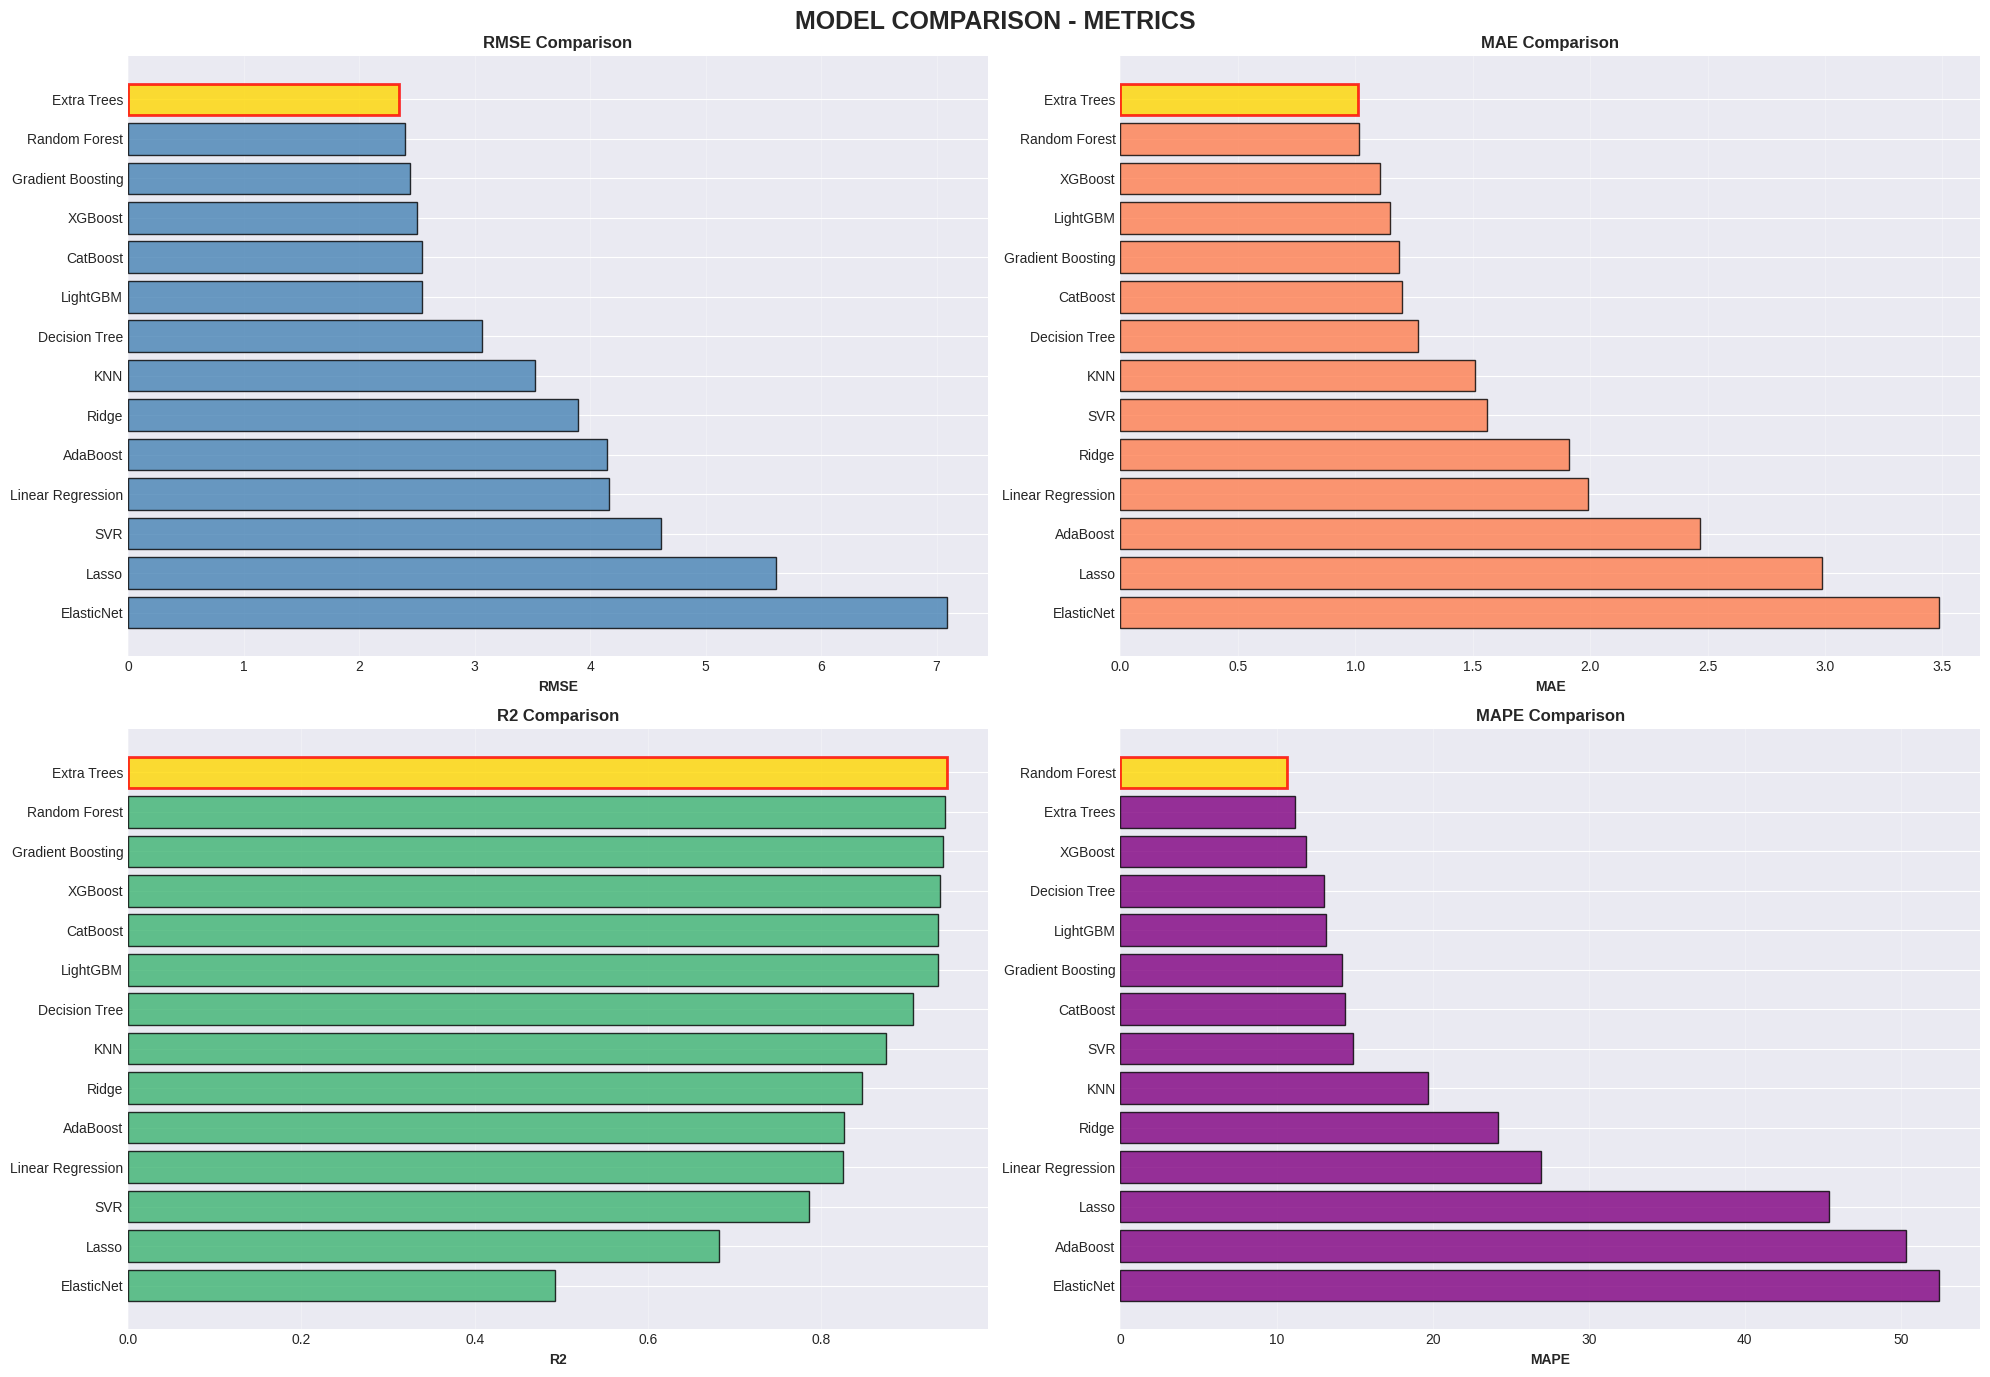

In [21]:
# Visual comparison
if results:
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('MODEL COMPARISON - METRICS', fontsize=18, fontweight='bold')

    metrics = ['RMSE', 'MAE', 'R2', 'MAPE']
    colors = ['steelblue', 'coral', 'mediumseagreen', 'purple']

    for idx, (metric, color) in enumerate(zip(metrics, colors)):
        ax = axes[idx // 2, idx % 2]

        sorted_df = results_df.sort_values(metric, ascending=(metric in ['RMSE', 'MAE', 'MAPE']))

        ax.barh(sorted_df['Model'], sorted_df[metric],
               color=color, edgecolor='black', alpha=0.8)
        ax.set_xlabel(metric, fontweight='bold')
        ax.set_title(f'{metric} Comparison', fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        ax.invert_yaxis()

        # Highlight best
        best_idx = 0
        ax.get_children()[best_idx].set_color('gold')
        ax.get_children()[best_idx].set_edgecolor('red')
        ax.get_children()[best_idx].set_linewidth(2)

    plt.tight_layout()
    plt.show()

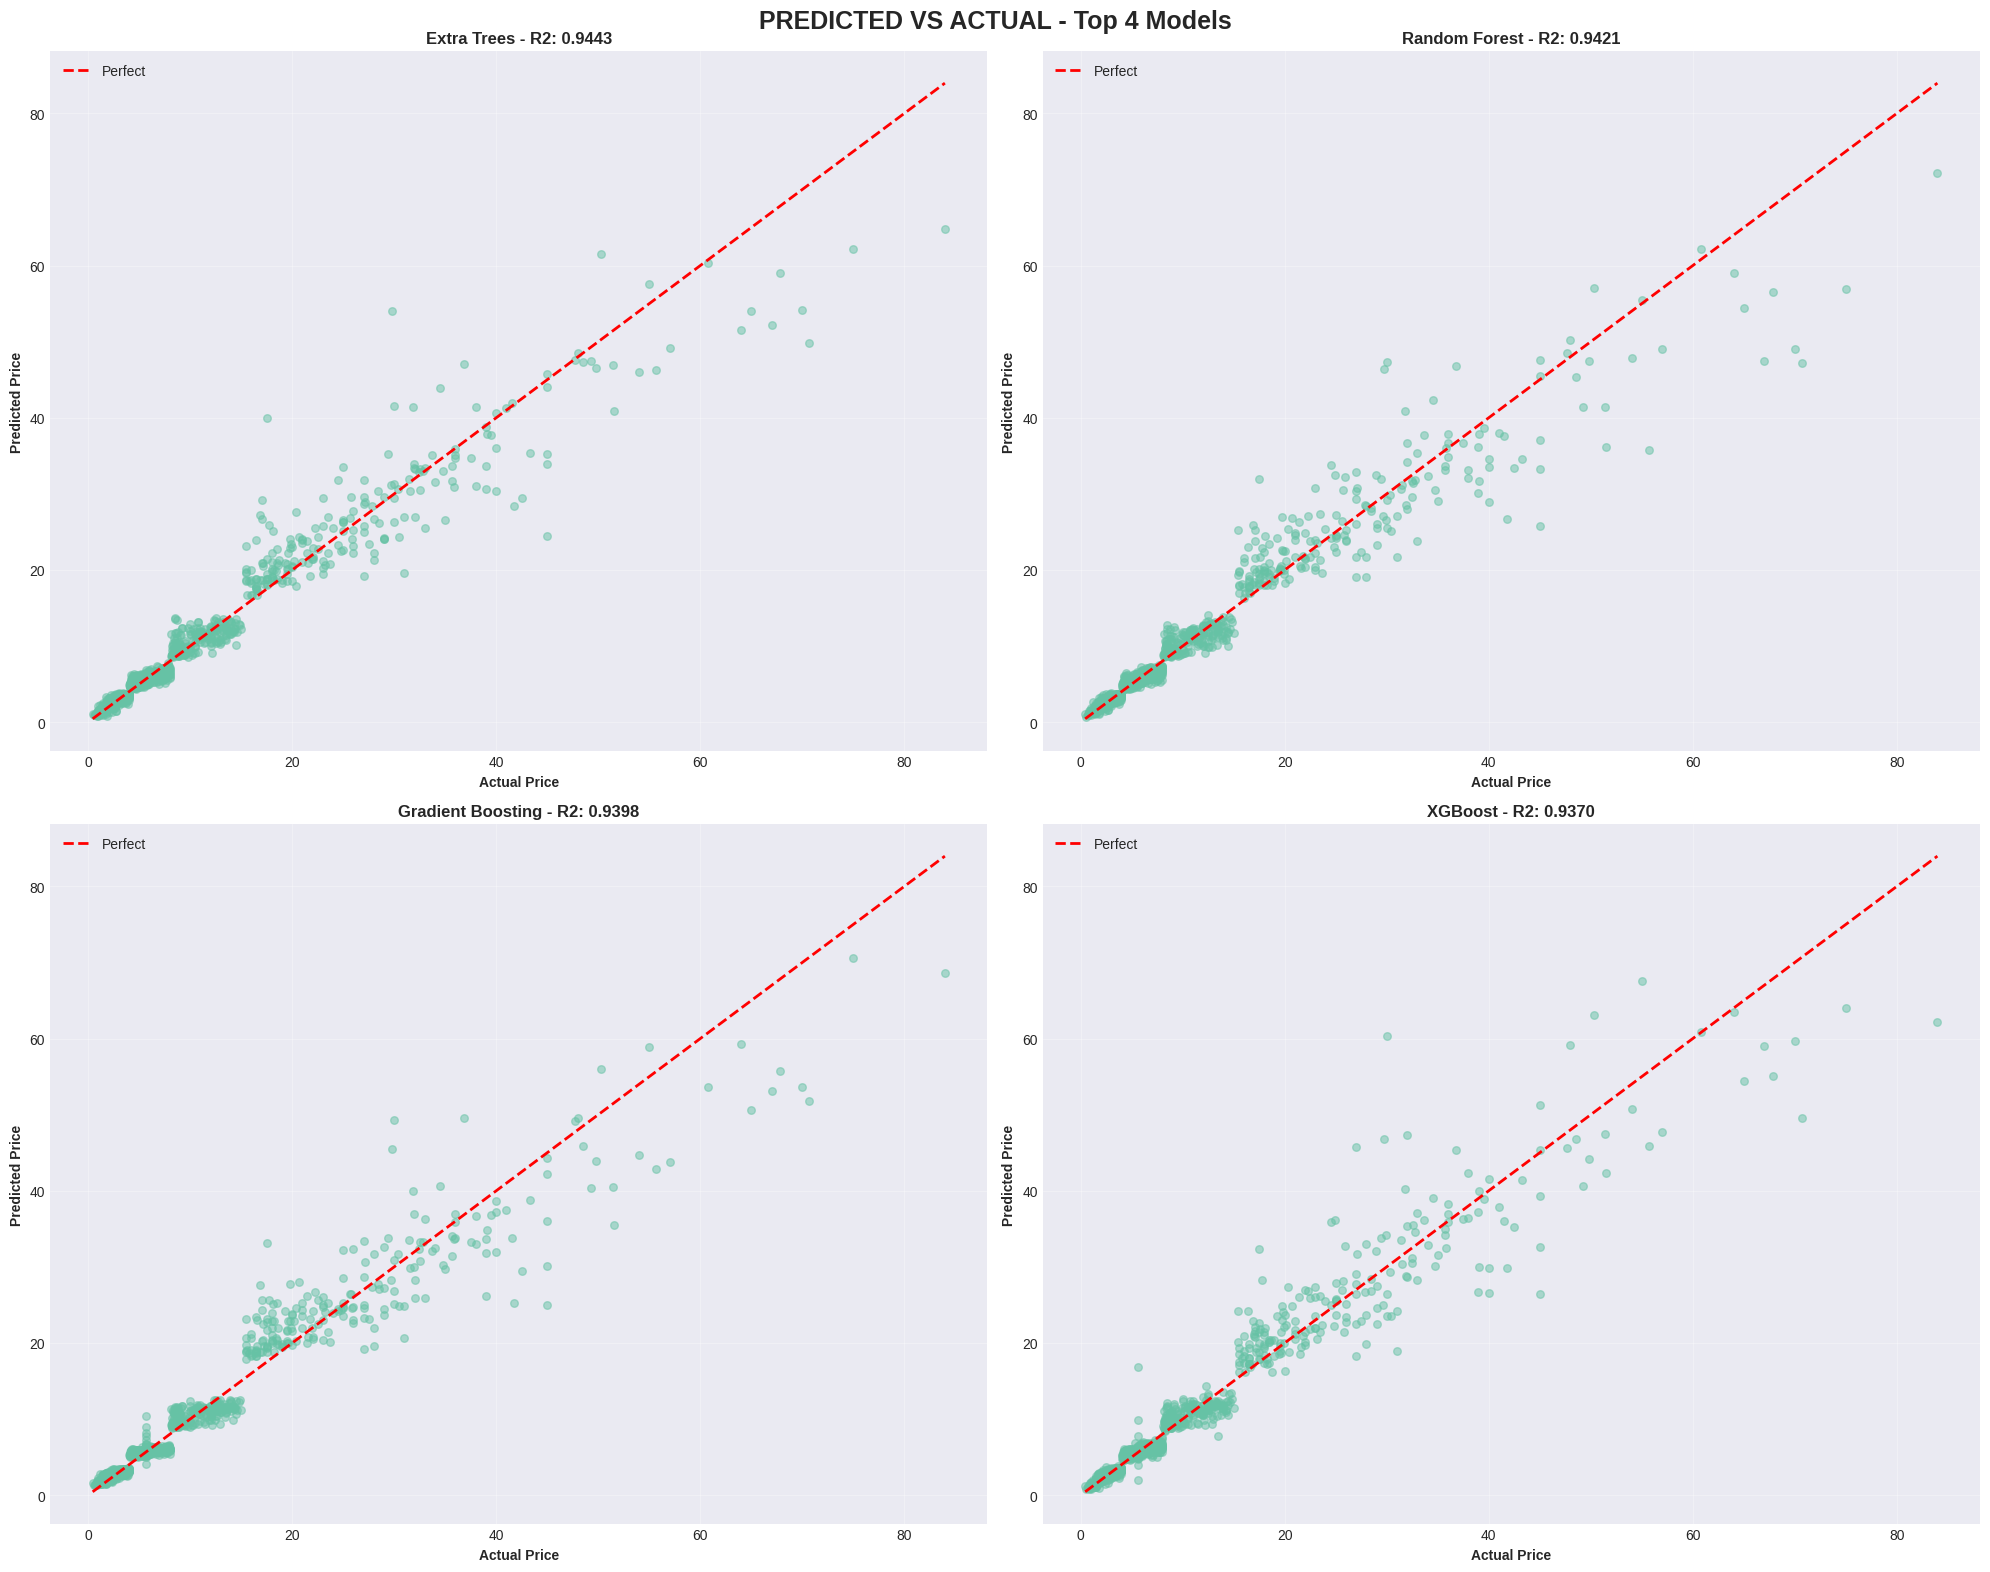

In [22]:
# Predicted vs Actual (top 4)
if results:
    top_4 = results_df.head(4)['Model'].tolist()

    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('PREDICTED VS ACTUAL - Top 4 Models', fontsize=18, fontweight='bold')

    for idx, model_name in enumerate(top_4):
        ax = axes[idx // 2, idx % 2]

        y_pred = results[model_name]['predictions']

        ax.scatter(y_test, y_pred, alpha=0.5, s=30)

        # Perfect prediction line
        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')

        ax.set_xlabel('Actual Price', fontweight='bold')
        ax.set_ylabel('Predicted Price', fontweight='bold')
        ax.set_title(f'{model_name} - R2: {results[model_name]["R2"]:.4f}', fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 8. FINAL RESULTS

In [23]:
print('='*100)
print('CARS DATASET - FINAL RESULTS')
print('='*100)

print('\n1. DATASET:')
print(f'   Total Cars: {len(df):,}')
print(f'   Features: {X.shape[1]}')
print(f'   Price Range: ${y.min():,.2f} - ${y.max():,.2f}')
print(f'   Average Price: ${y.mean():,.2f}')

if brand_cols:
    print(f'\n2. BRANDS:')
    print(f'   Total Brands: {df[brand_col].nunique()}')
    print(f'   Top Brand: {df[brand_col].value_counts().index[0]}')

if results:
    print(f'\n3. BEST MODEL:')
    print(f'   Model: {best_model}')
    print(f'   R2 Score: {results_df.iloc[0]["R2"]:.4f}')
    print(f'   RMSE: ${results_df.iloc[0]["RMSE"]:,.2f}')
    print(f'   MAE: ${results_df.iloc[0]["MAE"]:,.2f}')
    print(f'   MAPE: {results_df.iloc[0]["MAPE"]:.2f}%')

    print(f'\n4. TOP 5 MODELS:')
    for idx, row in results_df.head(5).iterrows():
        print(f'   {idx+1}. {row["Model"]:20} R2: {row["R2"]:.4f}')

print(f'\n5. KEY INSIGHTS:')
print(f'   - Price prediction possible with {results_df.iloc[0]["R2"]:.1%} accuracy')
print(f'   - Average prediction error: ${results_df.iloc[0]["MAE"]:,.2f}')
print(f'   - Car age, mileage, brand are key price factors')
print(f'   - {len(results)} regression models trained successfully')

print('\n' + '='*100)
print('CARS ANALYSIS COMPLETE!')
print('='*100)

CARS DATASET - FINAL RESULTS

1. DATASET:
   Total Cars: 7,253
   Features: 2735
   Price Range: $0.44 - $160.00
   Average Price: $8.83

3. BEST MODEL:
   Model: Extra Trees
   R2 Score: 0.9443
   RMSE: $2.35
   MAE: $1.01
   MAPE: 11.20%

4. TOP 5 MODELS:
   1. Extra Trees          R2: 0.9443
   2. Random Forest        R2: 0.9421
   3. Gradient Boosting    R2: 0.9398
   4. XGBoost              R2: 0.9370
   5. CatBoost             R2: 0.9345

5. KEY INSIGHTS:
   - Price prediction possible with 94.4% accuracy
   - Average prediction error: $1.01
   - Car age, mileage, brand are key price factors
   - 14 regression models trained successfully

CARS ANALYSIS COMPLETE!
